<a href="https://colab.research.google.com/github/MsTejasviSingh/RNA-seq-transcriptomics/blob/main/02_RNAseq_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loading Gene Count Data

The FeatureCounts output file contains the number of sequencing reads assigned to each gene across all RNA-seq samples.

In this step, the count matrix is imported into Python using pandas so that it can be explored and analyzed.

Rows represent genes, while columns represent samples.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
project_path = '/content/drive/MyDrive/RNAseq_Project'

bam_path = f"{project_path}/Sorted_BAM"
gtf_path = f"{project_path}/chrX_data/genes/chrX.gtf"

print("Project:", project_path)
print("BAM Folder:", bam_path)
print("GTF Folder:", gtf_path)


Project: /content/drive/MyDrive/RNAseq_Project
BAM Folder: /content/drive/MyDrive/RNAseq_Project/Sorted_BAM
GTF Folder: /content/drive/MyDrive/RNAseq_Project/chrX_data/genes/chrX.gtf


In [ ]:
!ls -lh "/content/drive/MyDrive/RNAseq_Project/Sorted_BAM" | head
!ls -lh "/content/drive/MyDrive/RNAseq_Project/chrX_data/genes"

total 1.5G
-rw------- 1 root root 144M Aug 22 16:45 ERR188044_chrX.sorted.bam
-rw------- 1 root root 163K Aug 22 16:54 ERR188044_chrX.sorted.bam.bai
-rw------- 1 root root 139M Aug 22 16:45 ERR188104_chrX.sorted.bam
-rw------- 1 root root 161K Aug 22 16:54 ERR188104_chrX.sorted.bam.bai
-rw------- 1 root root 185M Aug 22 16:45 ERR188234_chrX.sorted.bam
-rw------- 1 root root 167K Aug 22 16:54 ERR188234_chrX.sorted.bam.bai
-rw------- 1 root root 101M Aug 22 16:45 ERR188245_chrX.sorted.bam
-rw------- 1 root root 146K Aug 22 16:54 ERR188245_chrX.sorted.bam.bai
-rw------- 1 root root 113M Aug 22 16:46 ERR188257_chrX.sorted.bam
total 6.5M
-rw------- 1 root root 6.5M Aug 20 16:55 chrX.gtf


In [3]:
!apt-get install -y subread

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  subread
0 upgraded, 1 newly installed, 0 to remove and 1 not upgraded.
Need to get 565 kB of archives.
After this operation, 1,928 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 subread amd64 2.0.3+dfsg-1 [565 kB]
Fetched 565 kB in 1s (407 kB/s)
Selecting previously unselected package subread.
(Reading database ... 118419 files and directories currently installed.)
Preparing to unpack .../subread_2.0.3+dfsg-1_amd64.deb ...
Unpacking subread (2.0.3+dfsg-1) ...
Setting up subread (2.0.3+dfsg-1) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
!featureCounts -v


featureCounts v2.0.3



In [ ]:
!mkdir "/content/drive/MyDrive/RNAseq_Project/FeatureCounts"

In [ ]:
!featureCounts \
-T 2\
-p \
-a "/content/drive/MyDrive/RNAseq_Project/chrX_data/genes/chrX.gtf"\
-o "/content/drive/MyDrive/RNAseq_Project/FeatureCountsgene_counts.txt"\
/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/*.sorted.bam


        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
	  v2.0.3

//========================== featureCounts setting ===========================\\
||                                                                            ||
||             Input files : 12 BAM files                                     ||
||                                                                            ||
||                           ERR188044_chrX.sorted.bam                        ||
||                           ERR188104_chrX.sorted.bam                        ||
||                           ERR188234_chrX.sorted.bam           

In [ ]:
!ls -lh "/content/drive/MyDrive/RNAseq_Project" | grep FeatureCounts

drwx------ 2 root root 4.0K Aug 23 14:37 FeatureCounts
-rw------- 1 root root 576K Aug 23 14:45 FeatureCountsgene_counts.txt
-rw------- 1 root root 1.8K Aug 23 14:45 FeatureCountsgene_counts.txt.summary
-rw------- 1 root root 1.8K Aug 23 14:41 FeatureCounts.summary


# Exploring the Count Matrix

Before performing any analysis, it is important to inspect the dataset.

The dimensions of the matrix are checked to determine the number of genes and samples. Column names are also examined to verify that all RNA-seq samples were imported correctly.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mv "/content/drive/MyDrive/RNAseq_Project/FeatureCountsgene_counts.txt" \
"/content/drive/MyDrive/RNAseq_Project/FeatureCounts/"

!mv "/content/drive/MyDrive/RNAseq_Project/FeatureCountsgene_counts.txt.summary" \
"/content/drive/MyDrive/RNAseq_Project/FeatureCounts/"

!mv "/content/drive/MyDrive/RNAseq_Project/FeatureCounts.summary" \
"/content/drive/MyDrive/RNAseq_Project/FeatureCounts/"

In [ ]:
!ls -lh "/content/drive/MyDrive/RNAseq_Project/FeatureCounts/"

total 580K
-rw------- 1 root root 576K Aug 23 14:45 FeatureCountsgene_counts.txt
-rw------- 1 root root 1.8K Aug 23 14:45 FeatureCountsgene_counts.txt.summary
-rw------- 1 root root 1.8K Aug 23 14:41 FeatureCounts.summary


In [4]:
import pandas as pd

counts = pd.read_csv("/content/drive/MyDrive/RNAseq_Project/FeatureCounts/FeatureCountsgene_counts.txt", sep="\t",comment="#")

counts.head()


,Geneid,Chr,Start,End,Strand,Length,/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188044_chrX.sorted.bam,/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188104_chrX.sorted.bam,/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188234_chrX.sorted.bam,/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188245_chrX.sorted.bam,/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188257_chrX.sorted.bam,/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188273_chrX.sorted.bam,/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188337_chrX.sorted.bam,/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188383_chrX.sorted.bam,/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188401_chrX.sorted.bam,/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188428_chrX.sorted.bam,/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188454_chrX.sorted.bam,/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR204916_chrX.sorted.bam
0,NM_033031,chrX;chrX;chrX;chrX;chrX;chrX;chrX;chrX;chrX;c...,50284540;50285127;50288780;50294863;50308505;5...,50284616;50285259;50288887;50294993;50311496;5...,+;+;+;+;+;+;+;+;+;+;+;+,4511,26,31,6,6,6,6,14,8,20,5,29,14
1,NM_033670,chrX;chrX;chrX;chrX;chrX;chrX;chrX;chrX,50284540;50285127;50288780;50342202;50346652;5...,50284616;50285259;50288887;50342339;50346807;5...,+;+;+;+;+;+;+;+,1199,0,0,0,0,0,0,0,0,0,0,0,0
2,NM_144969,chrX;chrX;chrX;chrX;chrX;chrX;chrX;chrX;chrX;c...,75368427;75379120;75417087;75421864;75424652;7...,75372945;75379198;75417190;75421990;75424784;7...,-;-;-;-;-;-;-;-;-;-;-;-,6043,0,0,0,0,0,0,0,0,0,0,0,0
3,NM_001168362,chrX;chrX;chrX;chrX;chrX,91835461;91876781;92387735;92468299;92618264,91836044;91879273;92387933;92468322;92623229,+;+;+;+;+,8266,0,0,0,0,0,0,0,0,0,0,0,0
4,NM_001168361,chrX;chrX;chrX;chrX;chrX;chrX;chrX,91835461;91876781;92201375;92263114;92287967;9...,91836044;91879273;92201455;92263143;92288002;9...,+;+;+;+;+;+;+,8214,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
counts.shape

(2082, 18)

In [ ]:
counts.columns.tolist()

['Geneid',
 'Chr',
 'Start',
 'End',
 'Strand',
 'Length',
 '/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188044_chrX.sorted.bam',
 '/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188104_chrX.sorted.bam',
 '/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188234_chrX.sorted.bam',
 '/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188245_chrX.sorted.bam',
 '/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188257_chrX.sorted.bam',
 '/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188273_chrX.sorted.bam',
 '/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188337_chrX.sorted.bam',
 '/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188383_chrX.sorted.bam',
 '/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188401_chrX.sorted.bam',
 '/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188428_chrX.sorted.bam',
 '/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR188454_chrX.sorted.bam',
 '/content/drive/MyDrive/RNAseq_Project/Sorted_BAM/ERR204916_chrX.sorted

# Cleaning Sample Names

FeatureCounts uses the full BAM file path as the column name for each sample.

To make downstream analysis easier, the file paths are replaced with simple sample IDs such as ERR188044 and ERR188104.

In [5]:
from google import colab
clean_counts = counts.copy()

#Replacing column names
clean_counts.columns = [
    col.split("/")[-1].replace("_chrX.sorted.bam","")

if ".bam" in col

#Otherwise column name unchanged
else col

for col in clean_counts.columns]

clean_counts.columns


Index(['Geneid', 'Chr', 'Start', 'End', 'Strand', 'Length', 'ERR188044',
       'ERR188104', 'ERR188234', 'ERR188245', 'ERR188257', 'ERR188273',
       'ERR188337', 'ERR188383', 'ERR188401', 'ERR188428', 'ERR188454',
       'ERR204916'],
      dtype='object')

In [6]:
expression = clean_counts.drop(

columns = ["Chr","Start","End","Strand","Length"]

)

expression.head()

,Geneid,ERR188044,ERR188104,ERR188234,ERR188245,ERR188257,ERR188273,ERR188337,ERR188383,ERR188401,ERR188428,ERR188454,ERR204916
0,NM_033031,26,31,6,6,6,6,14,8,20,5,29,14
1,NM_033670,0,0,0,0,0,0,0,0,0,0,0,0
2,NM_144969,0,0,0,0,0,0,0,0,0,0,0,0
3,NM_001168362,0,0,0,0,0,0,0,0,0,0,0,0
4,NM_001168361,0,0,0,0,0,0,0,0,0,0,0,0


In [7]:
sample_data = expression.iloc[:,1:]

#Checking each sample, and is the sum equals to zero then gene is not expressed anywhere

zero_genes = (sample_data.sum(axis=1)==0)

zero_genes.sum()

np.int64(1302)

In [8]:
expression["Total_Count"] = sample_data.sum(axis=1)

#Sorting genes from highest to lowest counts
top_genes = expression.sort_values(
    by="Total_Count",
    ascending=False
)

top_genes[["Geneid", "Total_Count"]].head(10)

,Geneid,Total_Count
156,NM_021109,4224078
1266,NM_001007,1124980
386,NM_000291,1027681
1186,NM_002444,639628
654,NM_001636,465133
311,NM_031407,401957
798,NM_001415,253723
1578,NM_001152,253263
960,NM_006743,213387
1638,NM_018990,185776


# Loading Sample Metadata

The metadata file contains information about each RNA-seq sample, including biological sex and population group.

This information is required for downstream comparative analyses because it provides the biological context needed to interpret gene expression differences between samples.

In [9]:
pheno = pd.read_csv("/content/drive/MyDrive/RNAseq_Project/chrX_data/geuvadis_phenodata.csv")

pheno

,ids,sex,population
0,ERR188044,male,YRI
1,ERR188104,male,YRI
2,ERR188234,female,YRI
3,ERR188245,female,GBR
4,ERR188257,male,GBR
5,ERR188273,female,YRI
6,ERR188337,female,GBR
7,ERR188383,male,GBR
8,ERR188401,male,GBR
9,ERR188428,female,GBR


In [10]:
pheno.shape

(12, 3)

In [ ]:
pheno.columns

Index(['ids', 'sex', 'population'], dtype='object')

# Evaluating Library Sizes

Library sizes provide an estimate of sequencing depth and help identify samples with unusually low or high numbers of assigned reads.

The samples in this dataset show variation in library size, ranging from approximately 0.6 million to 1.6 million assigned reads. Such variation is expected in RNA-seq experiments and will be accounted for during normalization.

In [11]:
# Only the sample columns
sample_counts = expression.iloc[:, 1:13]

# Total counts per sample
library_sizes = sample_counts.sum()

library_sizes

,0
ERR188044,1252066
ERR188104,1256650
ERR188234,1568219
ERR188245,829093
ERR188257,910134
ERR188273,594576
ERR188337,1145649
ERR188383,926556
ERR188401,1260627
ERR188428,830168


The count matrix contains expression counts for 2,082 genes across 12 RNA-seq samples. To assess sequencing depth, total counts were summed across all genes for each sample. The resulting bar plot shows variation in library size between samples, ranging from approximately 0.6 million to 1.6 million mapped reads. Such differences are expected in RNA-seq experiments and motivate the need for normalization before comparing gene expression levels between samples.

In [12]:
print(type(sample_counts))
print(sample_counts.shape)

sample_counts.head()

<class 'pandas.core.frame.DataFrame'>
(2082, 12)


,ERR188044,ERR188104,ERR188234,ERR188245,ERR188257,ERR188273,ERR188337,ERR188383,ERR188401,ERR188428,ERR188454,ERR204916
0,26,31,6,6,6,6,14,8,20,5,29,14
1,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
sample_counts.describe()

,ERR188044,ERR188104,ERR188234,ERR188245,ERR188257,ERR188273,ERR188337,ERR188383,ERR188401,ERR188428,ERR188454,ERR204916
count,2082.000000,2082.00000,2082.000000,2082.000000,2082.000000,2082.000000,2082.000000,2082.000000,2082.000000,2082.000000,2082.000000,2082.000000
mean,601.376561,603.57829,753.227185,398.219500,437.144092,285.579251,550.263689,445.031700,605.488473,398.735831,466.015370,506.999039
std,10331.301602,10463.82273,13958.203343,6053.532733,8175.761237,5095.603582,8401.154493,7246.303914,10753.110300,6595.116921,7480.996869,7334.536870
min,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.00000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.750000,1.000000
max,434614.000000,436007.00000,586143.000000,231416.000000,358226.000000,214336.000000,346466.000000,297950.000000,465692.000000,268860.000000,311980.000000,272388.000000


In [13]:
total_reads = sample_counts.sum(axis=0) #axis=0; how many reads does each sample have?

print(type(total_reads))

print(total_reads.shape)

print(total_reads)

<class 'pandas.core.series.Series'>
(12,)
ERR188044    1252066
ERR188104    1256650
ERR188234    1568219
ERR188245     829093
ERR188257     910134
ERR188273     594576
ERR188337    1145649
ERR188383     926556
ERR188401    1260627
ERR188428     830168
ERR188454     970244
ERR204916    1055572
dtype: int64


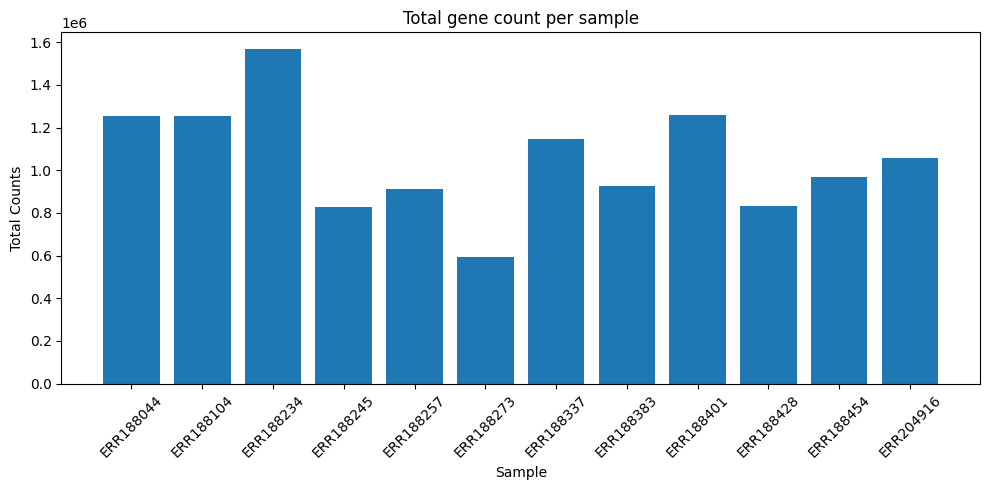

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(total_reads.index, total_reads.values)

plt.xlabel("Sample")

plt.ylabel("Total Counts")

plt.title("Total gene count per sample")

#Roatate sample names so they do not overlap
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [15]:
gene_totals = sample_counts.sum(axis=1) #axis=1; how stringly is the gene expressed across each sample?

gene_totals.sort_values(ascending=False).head(10)

,0
156,4224078
1266,1124980
386,1027681
1186,639628
654,465133
311,401957
798,253723
1578,253263
960,213387
1638,185776


In [16]:
sample_counts.index[:10]

RangeIndex(start=0, stop=10, step=1)

In [17]:
print(sample_counts.columns)

Index(['ERR188044', 'ERR188104', 'ERR188234', 'ERR188245', 'ERR188257',
       'ERR188273', 'ERR188337', 'ERR188383', 'ERR188401', 'ERR188428',
       'ERR188454', 'ERR204916'],
      dtype='object')


In [18]:
sample_counts.head()

,ERR188044,ERR188104,ERR188234,ERR188245,ERR188257,ERR188273,ERR188337,ERR188383,ERR188401,ERR188428,ERR188454,ERR204916
0,26,31,6,6,6,6,14,8,20,5,29,14
1,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0


In [19]:
import numpy as np

In [20]:
#Since RNAseq data is highly skewed;
#log-transformed counts are performed to compress verly large values

log_counts = np.log2(sample_counts + 1)
#+1 prevents taking log of 0

print(log_counts.shape)
log_counts.head()

(2082, 12)


,ERR188044,ERR188104,ERR188234,ERR188245,ERR188257,ERR188273,ERR188337,ERR188383,ERR188401,ERR188428,ERR188454,ERR204916
0,4.754888,5.0,2.807355,2.807355,2.807355,2.807355,3.906891,3.169925,4.392317,2.584963,4.906891,3.906891
1,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [21]:
print("Raw Counts")
print(sample_counts.describe())

print("\n")
print("Log-transformed counts")
print(log_counts.describe())

Raw Counts
           ERR188044     ERR188104      ERR188234      ERR188245  \
count    2082.000000    2082.00000    2082.000000    2082.000000   
mean      601.376561     603.57829     753.227185     398.219500   
std     10331.301602   10463.82273   13958.203343    6053.532733   
min         0.000000       0.00000       0.000000       0.000000   
25%         0.000000       0.00000       0.000000       0.000000   
50%         0.000000       0.00000       0.000000       0.000000   
75%         1.000000       1.00000       1.000000       0.000000   
max    434614.000000  436007.00000  586143.000000  231416.000000   

           ERR188257      ERR188273      ERR188337      ERR188383  \
count    2082.000000    2082.000000    2082.000000    2082.000000   
mean      437.144092     285.579251     550.263689     445.031700   
std      8175.761237    5095.603582    8401.154493    7246.303914   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.000000       0.00

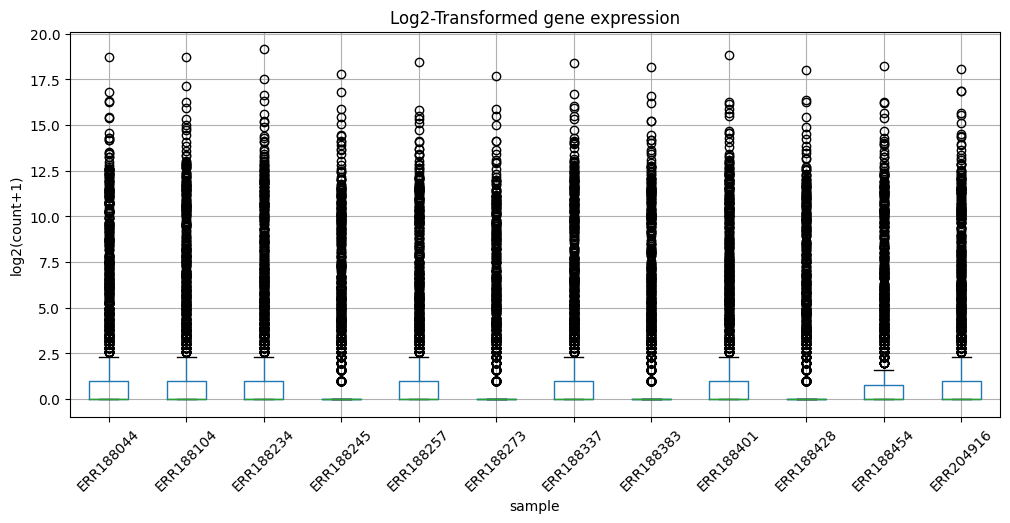

In [22]:
plt.figure(figsize=(12,5))

log_counts.boxplot(rot=45)

plt.title("Log2-Transformed gene expression")
plt.ylabel("log2(count+1)")
plt.xlabel("sample")

plt.show()

In [23]:
pheno.head()

,ids,sex,population
0,ERR188044,male,YRI
1,ERR188104,male,YRI
2,ERR188234,female,YRI
3,ERR188245,female,GBR
4,ERR188257,male,GBR


In [24]:
#PCA require row = sample and columns = feature(genes)
#Our data row = genes and columns = sample
#Hence we transpose them

pca_input = log_counts.T

print(pca_input.shape)

(12, 2082)


In [25]:
from sklearn.decomposition import PCA

In [26]:
#Reduces 2082 gene dimensions down to
#Only 2 principal components (PC1 and PC2)
pca = PCA(n_components=2)

pca_results = pca.fit_transform(pca_input)

print(pca_results.shape)

(12, 2)


In [27]:
pca_df = pd.DataFrame(
    pca_results,
    columns=["PC1", "PC2"]
)

pca_df["Sample"] = pca_input.index

pca_df.head()

,PC1,PC2,Sample
0,-9.789412,-14.112532,ERR188044
1,-11.255054,-11.717239,ERR188104
2,-4.729609,-9.643740,ERR188234
3,14.589834,10.880878,ERR188245
4,0.519581,10.489220,ERR188257


In [41]:
# Percentage of variation explained by each principal component
explained_variance = pca.explained_variance_ratio_ * 100

print(explained_variance)

[22.48898096 16.50640938]


In [35]:
pheno_copy = pheno.copy()

pca_df = pca_df.merge(
    pheno_copy,
    left_on="Sample",
    right_on="ids"
)

pca_df.head()

,PC1,PC2,Sample,ids,sex,population
0,-9.789412,-14.112532,ERR188044,ERR188044,male,YRI
1,-11.255054,-11.717239,ERR188104,ERR188104,male,YRI
2,-4.729609,-9.643740,ERR188234,ERR188234,female,YRI
3,14.589834,10.880878,ERR188245,ERR188245,female,GBR
4,0.519581,10.489220,ERR188257,ERR188257,male,GBR


In [40]:
print([x for x in dir() if "variance" in x.lower()])

[]


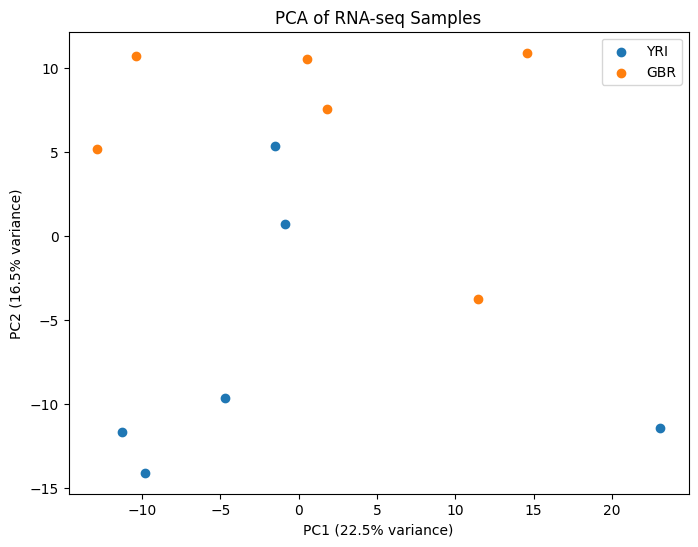

In [42]:
plt.figure(figsize=(8,6))

for population in pca_df["population"].unique():

  subset = pca_df[pca_df["population"]==population]

  plt.scatter(
      subset["PC1"],
      subset["PC2"],
      label=population
  )

plt.xlabel(f"PC1 ({explained_variance[0]:.1f}% variance)")
plt.ylabel(f"PC2 ({explained_variance[1]:.1f}% variance)")

plt.title("PCA of RNA-seq Samples")
plt.legend()

plt.show()